### Import Modules

In [1]:
import pandas as pd,numpy as np
from sklearn.svm import SVC,LinearSVC,NuSVC
from sklearn.model_selection import train_test_split,cross_val_score, StratifiedKFold,GridSearchCV
from sklearn.preprocessing import LabelEncoder,StandardScaler,MinMaxScaler,normalize
from sklearn.metrics import accuracy_score,classification_report
import joblib
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from umap import UMAP
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline

/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load Dataset

In [2]:
data = pd.read_csv("./embeddings_result/embeddings_call_graph_clusters_v2.csv")
data['code_file'] = data['code_file'].apply(lambda x: x.replace('/root/AI-Pattern-Mining-Project/outputs/prompt & rag/20251028_085918 - Run/generated_code/',''))
data['pattern'] = data['code_file'].apply(lambda x: x.split('/')[0])

In [3]:
data.head()

,code_file,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7,dim_8,...,dim_759,dim_760,dim_761,dim_762,dim_763,dim_764,dim_765,dim_766,dim_767,pattern
0,Advanced MT Prompting/pattern_1.py,0.008525,-0.190404,-0.002678,0.109558,-0.149338,-0.015497,-0.002739,-0.163714,0.035823,...,-0.020440,-0.034098,0.127237,0.034867,0.036119,0.396191,-0.162014,-0.008755,0.192776,Advanced MT Prompting
1,Advanced MT Prompting/pattern_10.py,0.003148,-0.154247,-0.018378,0.109571,-0.133392,-0.027548,0.018564,-0.133213,0.030589,...,-0.019897,-0.051971,0.127128,0.066161,0.025146,0.391820,-0.205718,0.014096,0.121679,Advanced MT Prompting
2,Advanced MT Prompting/pattern_11.py,-0.000473,-0.199095,-0.024379,0.095847,-0.138792,-0.012554,0.002148,-0.176035,0.042417,...,-0.024046,-0.045352,0.143503,0.057276,0.029717,0.420159,-0.237789,0.003915,0.154167,Advanced MT Prompting
3,Advanced MT Prompting/pattern_12.py,0.016030,-0.193469,0.001521,0.100525,-0.102650,-0.121538,0.017241,-0.197112,0.069094,...,0.019782,-0.054770,0.114624,0.046622,0.047399,0.395274,-0.168212,-0.044403,0.211058,Advanced MT Prompting
4,Advanced MT Prompting/pattern_13.py,0.004324,-0.220477,-0.005859,0.139539,-0.176770,-0.052713,0.009045,-0.183556,0.044746,...,-0.030576,-0.018828,0.140990,0.034613,0.046899,0.453001,-0.168210,-0.032149,0.211387,Advanced MT Prompting


### Helper Functions

In [4]:
def print_scores(y_test, y_pred,target_names):
    print(classification_report(y_test, y_pred, target_names=target_names))

### Preprocess Data

In [5]:
le = LabelEncoder()
data['pattern_encoded'] = le.fit_transform(data['pattern'])
features_cols = [col for col in data.columns if col not in ['code_file','pattern','pattern_encoded']]

In [7]:
X = data[features_cols]
y = data['pattern_encoded']
# X = normalize(X)
scaler = StandardScaler()
X = scaler.fit_transform(X)


### Feature Selection

In [8]:
from sklearn.feature_selection import SelectKBest, f_classif
selector = SelectKBest(f_classif, k=442)
selector.fit(X, y)
X = selector.transform(X)

### Train Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### SVC Exp

In [10]:
svc_model = SVC(kernel='linear', probability=True, random_state=42)
svc_model.fit(X_train, y_train)

svc_pred = svc_model.predict(X_test)
print_scores(y_test, svc_pred, target_names=le.classes_)

                                                                           precision    recall  f1-score   support

                                                    Advanced MT Prompting       1.00      0.67      0.80         6
                                         Bias Mitigation & Output Quality       0.86      1.00      0.92         6
                                              Cross-lingual LLM Prompting       0.86      1.00      0.92         6
                                       Enhanced User Intent Comprehension       0.86      1.00      0.92         6
                                          Explainable AI (XAI) Techniques       1.00      1.00      1.00         6
                                          Integrating External Knlowladge       0.29      0.33      0.31         6
                                             Integrating Knlowladge Graph       1.00      0.83      0.91         6
                                        Iterative Optimizations and ReAct      

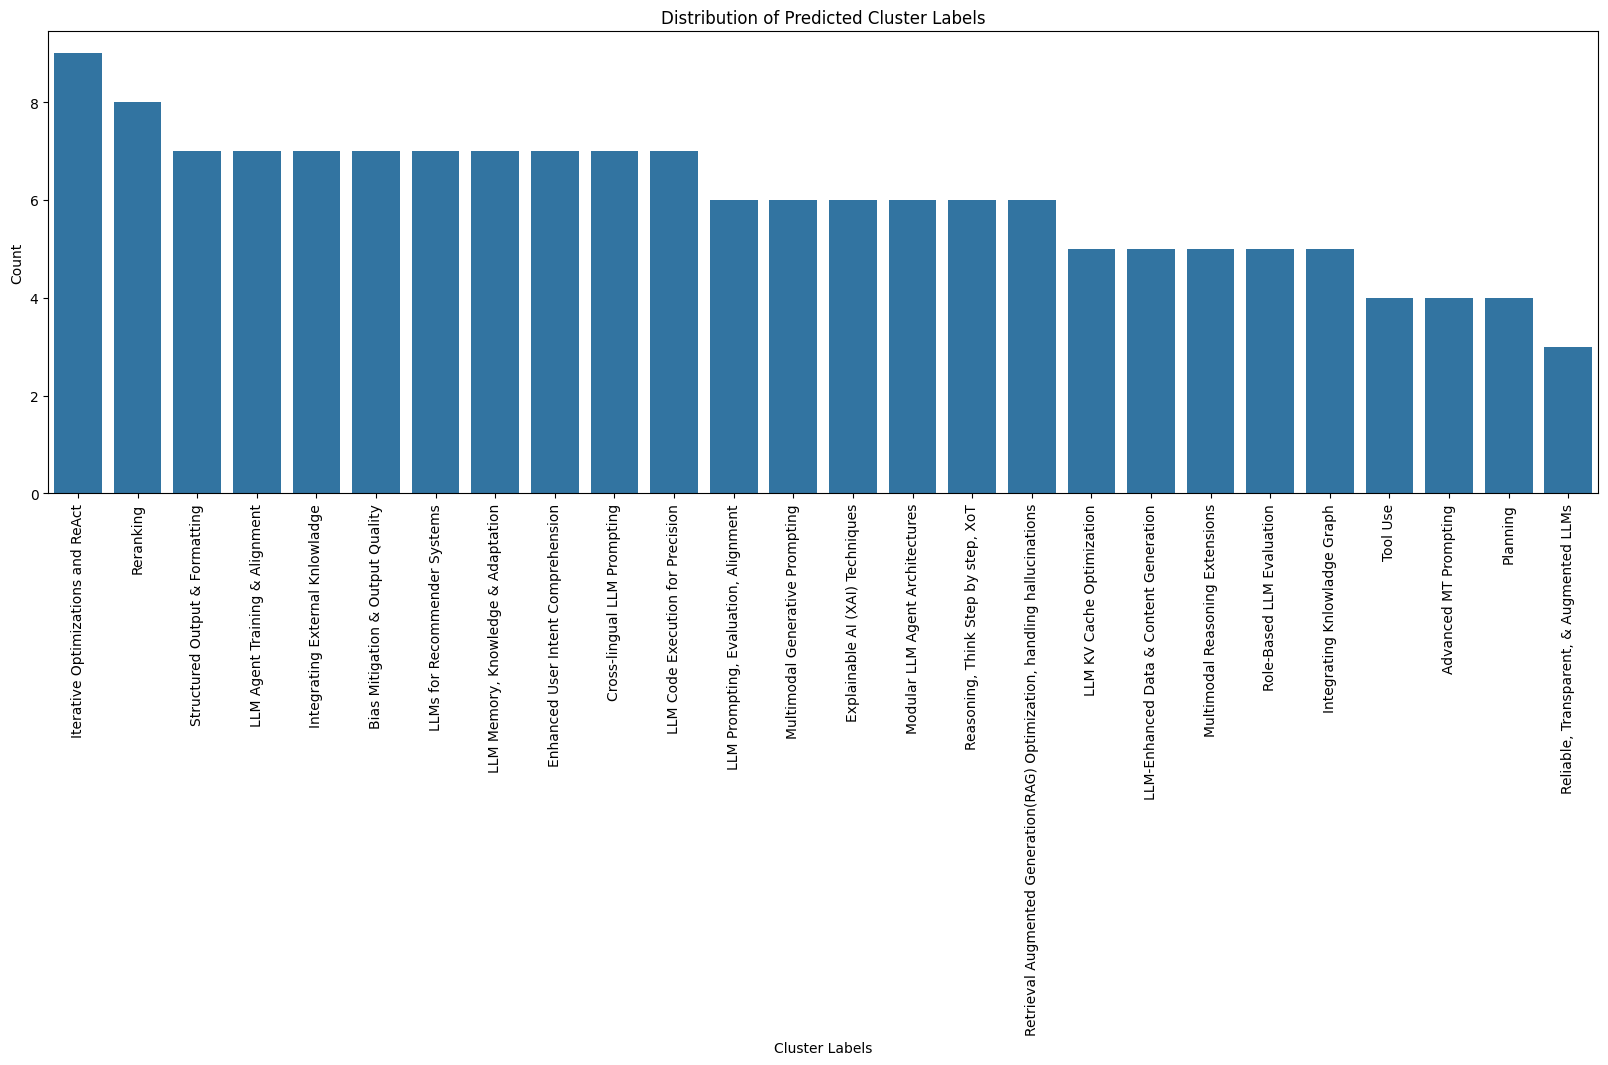

In [11]:
plt.figure(figsize=(20,6))
sns.countplot(x=le.inverse_transform(svc_pred), order=pd.Series(le.inverse_transform(svc_pred)).value_counts().index)
plt.title('Distribution of Predicted Cluster Labels')
plt.xlabel('Cluster Labels')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

In [10]:
params_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'gamma':[1,0.1,0.01,0.001,'scale','auto']
}

grid = GridSearchCV(SVC(),param_grid=params_grid,refit=True,cv=5,verbose=2)
grid.fit(X_train, y_train)
print("Best Parameters:",grid.best_params_)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.1s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.1s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.1s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.1s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.1s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.1s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.1s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.1s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.1s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.1s
[CV] END ........................C=0.1, gamma=1, kernel=poly; total time=   0.1s
[CV] END ........................C=0.1, gamma=1

In [11]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=2,)
svc_cv_scores = cross_val_score(svc_model, X, y, cv=kf, scoring='f1_weighted',)
print(f"SVC Cross-Validation F1 Scores: {svc_cv_scores}")
print(f"SVC Mean CV F1 Score: {np.mean(svc_cv_scores)}")

SVC Cross-Validation F1 Scores: [0.79473398 0.78937665 0.78577448 0.76057628 0.80617798]
SVC Mean CV F1 Score: 0.7873278757441653


### Other Model EXP

In [107]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=2)

In [108]:
def model_eval(model,name=''):
    cv_scores = cross_val_score(model, X, y, cv=kf, scoring='f1_weighted')
    print(f"Summary of model: ")
    print(f" - SVC Cross-Validation F1 Scores: {cv_scores}")
    print(f" - SVC Mean CV F1 Score: {np.mean(cv_scores)}")

In [109]:
model = KNeighborsClassifier(n_neighbors=2)
model_eval(model)

Summary of model: 
 - SVC Cross-Validation F1 Scores: [0.43815629 0.46660177 0.40706302 0.53799534 0.3940124 ]
 - SVC Mean CV F1 Score: 0.44876576415037944


In [110]:
model = RandomForestClassifier(n_estimators=26, random_state=1)
model_eval(model)

Summary of model: 
 - SVC Cross-Validation F1 Scores: [0.47051282 0.54034918 0.49280442 0.5719253  0.56321734]
 - SVC Mean CV F1 Score: 0.5277618108387339


In [111]:
model = DecisionTreeClassifier(random_state=1)
model_eval(model)

Summary of model: 
 - SVC Cross-Validation F1 Scores: [0.2707931  0.24960872 0.23336386 0.3535742  0.35392385]
 - SVC Mean CV F1 Score: 0.2922527472527473


### Final SVC Model Build and Save

In [12]:
final_svc_model = SVC(kernel='linear', probability=True, random_state=42)
final_svc_model.fit(X, y)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [13]:
pipeline = Pipeline(steps=[('scaler', scaler), ('selector', selector), ('svc', final_svc_model)])

In [14]:
predictions = pipeline.predict(data[features_cols])
accuracy = accuracy_score(y, predictions)
print(f"Overall Accuracy on entire dataset: {accuracy}")

Overall Accuracy on entire dataset: 1.0


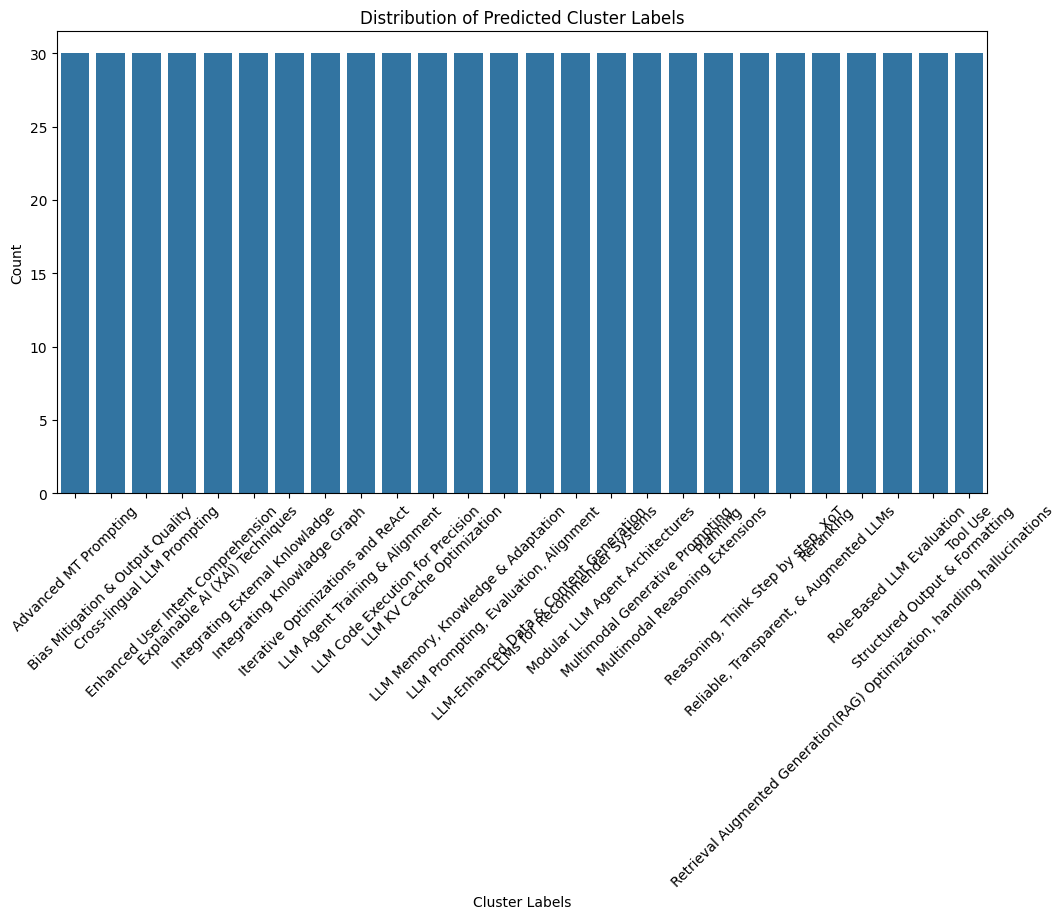

In [16]:
plt.figure(figsize=(12,6))
sns.countplot(x=le.inverse_transform(predictions), order=pd.Series(le.inverse_transform(predictions)).value_counts().index)
plt.title('Distribution of Predicted Cluster Labels')
plt.xlabel('Cluster Labels')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [17]:
joblib.dump(pipeline, './models/svc_classification_pipeline_v2.joblib')
joblib.dump(le, './models/label_encoder_v2.joblib')

['./models/label_encoder_v2.joblib']

### Clasify

In [61]:
data = pd.read_csv("/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/notebooks/embeddings_result/embeddings_call_graph_clusters_v2.csv")
data['cluster_file'] = data['code_file'].apply(lambda x: x.replace('/root/AI-Pattern-Mining-Project/outputs/prompt & rag/20251028_085918 - Run/generated_code/', ''))

In [97]:
cols = ["dim_0", "dim_3", "dim_4", "dim_6", "dim_7", "dim_11", "dim_12", "dim_14", "dim_16", "dim_18", "dim_20", "dim_21", "dim_22", "dim_23", "dim_24", "dim_26", "dim_27", "dim_29", "dim_33", "dim_34", "dim_37", "dim_38", "dim_40", "dim_41", "dim_43", "dim_44", "dim_45", "dim_46", "dim_49", "dim_50", "dim_51", "dim_53", "dim_54", "dim_55", "dim_58", "dim_62", "dim_63", "dim_65", "dim_66", "dim_67", "dim_69", "dim_70", "dim_71", "dim_72", "dim_73", "dim_76", "dim_79", "dim_80", "dim_81", "dim_83", "dim_84", "dim_85", "dim_87", "dim_88", "dim_90", "dim_91", "dim_95", "dim_96", "dim_98", "dim_99", "dim_100", "dim_101", "dim_104", "dim_107", "dim_109", "dim_110", "dim_111", "dim_115", "dim_116", "dim_118", "dim_119", "dim_120", "dim_123", "dim_124", "dim_125", "dim_128", "dim_129", "dim_131", "dim_132", "dim_134", "dim_136", "dim_137", "dim_139", "dim_143", "dim_148", "dim_151", "dim_152", "dim_154", "dim_155", "dim_159", "dim_160", "dim_161", "dim_162", "dim_164", "dim_167", "dim_168", "dim_169", "dim_170", "dim_171", "dim_173", "dim_175", "dim_177", "dim_178", "dim_180", "dim_182", "dim_183", "dim_184", "dim_185", "dim_186", "dim_189", "dim_190", "dim_192", "dim_193", "dim_195", "dim_196", "dim_197", "dim_199", "dim_200", "dim_201", "dim_202", "dim_204", "dim_205", "dim_207", "dim_208", "dim_211", "dim_212", "dim_213", "dim_215", "dim_216", "dim_218", "dim_223", "dim_224", "dim_225", "dim_228", "dim_231", "dim_235", "dim_238", "dim_240", "dim_242", "dim_243", "dim_250", "dim_251", "dim_252", "dim_254", "dim_255", "dim_258", "dim_259", "dim_260", "dim_263", "dim_266", "dim_267", "dim_269", "dim_271", "dim_273", "dim_274", "dim_275", "dim_276", "dim_277", "dim_282", "dim_284", "dim_286", "dim_287", "dim_288", "dim_289", "dim_291", "dim_293", "dim_294", "dim_295", "dim_296", "dim_297", "dim_298", "dim_300", "dim_302", "dim_304", "dim_305", "dim_306", "dim_308", "dim_309", "dim_312", "dim_313", "dim_314", "dim_315", "dim_316", "dim_317", "dim_318", "dim_320", "dim_321", "dim_322", "dim_324", "dim_326", "dim_328", "dim_329", "dim_332", "dim_333", "dim_334", "dim_335", "dim_339", "dim_340", "dim_341", "dim_342", "dim_346", "dim_347", "dim_349", "dim_350", "dim_353", "dim_354", "dim_355", "dim_356", "dim_357", "dim_358", "dim_359", "dim_360", "dim_361", "dim_363", "dim_364", "dim_368", "dim_369", "dim_371", "dim_372", "dim_373", "dim_375", "dim_377", "dim_381", "dim_382", "dim_383", "dim_384", "dim_388", "dim_390", "dim_391", "dim_392", "dim_393", "dim_395", "dim_397", "dim_398", "dim_399", "dim_400", "dim_401", "dim_402", "dim_403", "dim_404", "dim_405", "dim_406", "dim_407", "dim_409", "dim_410", "dim_411", "dim_412", "dim_414", "dim_416", "dim_417", "dim_418", "dim_419", "dim_421", "dim_429", "dim_430", "dim_434", "dim_437", "dim_439", "dim_441", "dim_443", "dim_446", "dim_448", "dim_451", "dim_452", "dim_462", "dim_463", "dim_465", "dim_467", "dim_469", "dim_470", "dim_471", "dim_473", "dim_474", "dim_477", "dim_478", "dim_480", "dim_481", "dim_482", "dim_483", "dim_485", "dim_486", "dim_487", "dim_490", "dim_492", "dim_498", "dim_500", "dim_501", "dim_503", "dim_505", "dim_506", "dim_509", "dim_510", "dim_511", "dim_513", "dim_515", "dim_516", "dim_518", "dim_520", "dim_522", "dim_523", "dim_524", "dim_525", "dim_529", "dim_531", "dim_532", "dim_533", "dim_535", "dim_538", "dim_545", "dim_549", "dim_550", "dim_552", "dim_555", "dim_557", "dim_559", "dim_561", "dim_562", "dim_564", "dim_566", "dim_567", "dim_569", "dim_571", "dim_573", "dim_574", "dim_575", "dim_578", "dim_579", "dim_582", "dim_583", "dim_584", "dim_585", "dim_586", "dim_587", "dim_588", "dim_589", "dim_592", "dim_593", "dim_594", "dim_596", "dim_597", "dim_598", "dim_599", "dim_600", "dim_601", "dim_607", "dim_608", "dim_611", "dim_612", "dim_614", "dim_616", "dim_617", "dim_618", "dim_619", "dim_621", "dim_623", "dim_624", "dim_626", "dim_628", "dim_630", "dim_631", "dim_632", "dim_634", "dim_635", "dim_637", "dim_639", "dim_641", "dim_642", "dim_643", "dim_646", "dim_647", "dim_654", "dim_655", "dim_656", "dim_658", "dim_659", "dim_660", "dim_661", "dim_662", "dim_666", "dim_667", "dim_668", "dim_669", "dim_672", "dim_675", "dim_676", "dim_677", "dim_678", "dim_679", "dim_681", "dim_686", "dim_688", "dim_689", "dim_691", "dim_693", "dim_694", "dim_695", "dim_696", "dim_697", "dim_698", "dim_699", "dim_700", "dim_702", "dim_703", "dim_705", "dim_706", "dim_708", "dim_709", "dim_710", "dim_711", "dim_712", "dim_713", "dim_715", "dim_716", "dim_718", "dim_720", "dim_721", "dim_723", "dim_725", "dim_726", "dim_727", "dim_728", "dim_729", "dim_730", "dim_734", "dim_737", "dim_738", "dim_740", "dim_742", "dim_743", "dim_747", "dim_748", "dim_749", "dim_750", "dim_754", "dim_755", "dim_756", "dim_757", "dim_758", "dim_760", "dim_761", "dim_763", "dim_766"]

In [ ]:
predictions = final_svc_model.predict(data[cols])

# predictions = final_svc_model.predict(X_test)

/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


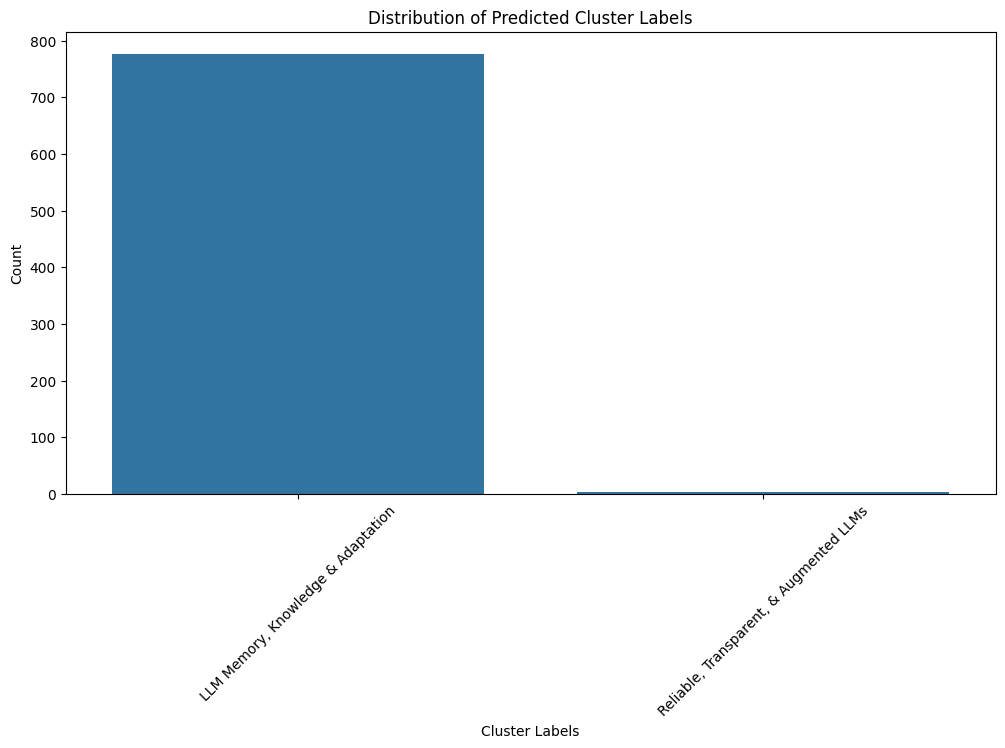

In [99]:
### Decode the labels
predicted_labels = le.inverse_transform(predictions)

### Visualize the results
plt.figure(figsize=(12,6))
sns.countplot(x=predicted_labels, order=pd.Series(predicted_labels).value_counts().index)
plt.title('Distribution of Predicted Cluster Labels')
plt.xlabel('Cluster Labels')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()